# Channel Signal Distributions

This notebook visualizes the per-channel (singlet, triplet, IR, quasiparticle/evaporation) signal distributions produced by `simulate_spectrum.py`.

**Sections:**
1. Theoretical yield curves (no simulation data needed)
2. Per-channel detected energy vs. recoil energy
3. Channel composition (stacked fractions)
4. Arrival time distributions
5. Spectrum-specific plots (WIMP masses, flat spectra, etc.)

In [11]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import HeST as H

## -------------------------------- ##
##        SET PLOTTING STYLE        ##
## -------------------------------- ##
matplotlib.rcParams['figure.figsize'] = 8.5,6
matplotlib.rcParams['figure.subplot.left'] = 0.15
matplotlib.rcParams['figure.subplot.right'] = 0.88
matplotlib.rcParams['figure.subplot.bottom'] = 0.15
matplotlib.rcParams['figure.subplot.top'] = 0.88
matplotlib.rcParams['axes.titlesize'] = 20
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.labelweight'] = 'normal'
matplotlib.rcParams['font.weight'] = 'normal' 
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['lines.linewidth'] = 2
matplotlib.rcParams['lines.markersize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['xtick.major.size'] = 8
matplotlib.rcParams['ytick.major.size'] = 8
matplotlib.rcParams['xtick.minor.size'] = 4
matplotlib.rcParams['ytick.minor.size'] = 4
matplotlib.rcParams['xtick.minor.visible'] = True 
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['xtick.direction'] = 'in' 
matplotlib.rcParams['ytick.direction'] = 'in' 
matplotlib.rcParams['xtick.top'] = True 
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.major.pad'] = 6
matplotlib.rcParams['image.cmap'] = 'viridis'

CHANNEL_NAMES = ['Singlet', 'Triplet', 'IR', 'QP/Evaporation']
CHANNEL_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

In [32]:
# Load simulation results — set this to the .npz file produced by simulate_spectrum.py
DATA_FILE = 'Sims/Spectrum_Flat_ER_energyMin_10_energyMax_10000_nEvents_10000_Heraldv1.npz'

data = np.load(DATA_FILE, allow_pickle=True)

print(list(data.keys()))

recoil_energies = data['recoil_energies']
recoil_types = data['recoil_types']  # 0 = ER, 1 = NR
n_quanta_generated = data['n_quanta_generated']  # (n_events, 4)
detected_energy = data['detected_energy']  # (n_events, 4)
detected_count = data['detected_count']  # (n_events, 4)
mean_arrival_time = data['mean_arrival_time']  # (n_events, 4)
spectrum_mode = str(data['spectrum_mode'])
detector_config = data['detector_config'].item()

has_wimp = 'wimp_mass' in data
if has_wimp:
    wimp_mass = float(data['wimp_mass'])

er_mask = recoil_types == 0
nr_mask = recoil_types == 1

print(f'Spectrum mode: {spectrum_mode}')
print(f'Recoil type: {"ER" if er_mask.any() else "NR"}')
print(f'Total events: {len(recoil_energies)}')
if has_wimp:
    print(f'WIMP mass: {wimp_mass} MeV')
print(f'Detector: {detector_config}')

['recoil_energies', 'recoil_types', 'n_quanta_generated', 'detected_energy', 'detected_count', 'mean_arrival_time', 'spectrum_mode', 'detector_config', 'sensor_det_energy', 'sensor_det_count', 'sensor_det_time']
Spectrum mode: flat
Recoil type: ER
Total events: 10000
Detector: {'detector_geometry': 'HeRALD_v1', 'fill_height': 4.5, 'cell_radius': 3.5, 'qp_wall_reflection_prob': 0.3, 'qp_wall_diffuse_prob': 0.0, 'qp_sensor_reflection_prob': 0.0, 'uv_wall_reflection_prob': 0.3, 'uv_wall_diffuse_prob': 0.0, 'ir_wall_reflection_prob': 0.0, 'ir_wall_diffuse_prob': 0.0, 'step_size': 0.05, 'max_dist': 10.0, 'qp_temperature': 2.0, 'max_qp_simulated': 100000, 'fano_singlet': 1.0, 'fano_triplet': 1.0, 'fano_ir': 1.0}


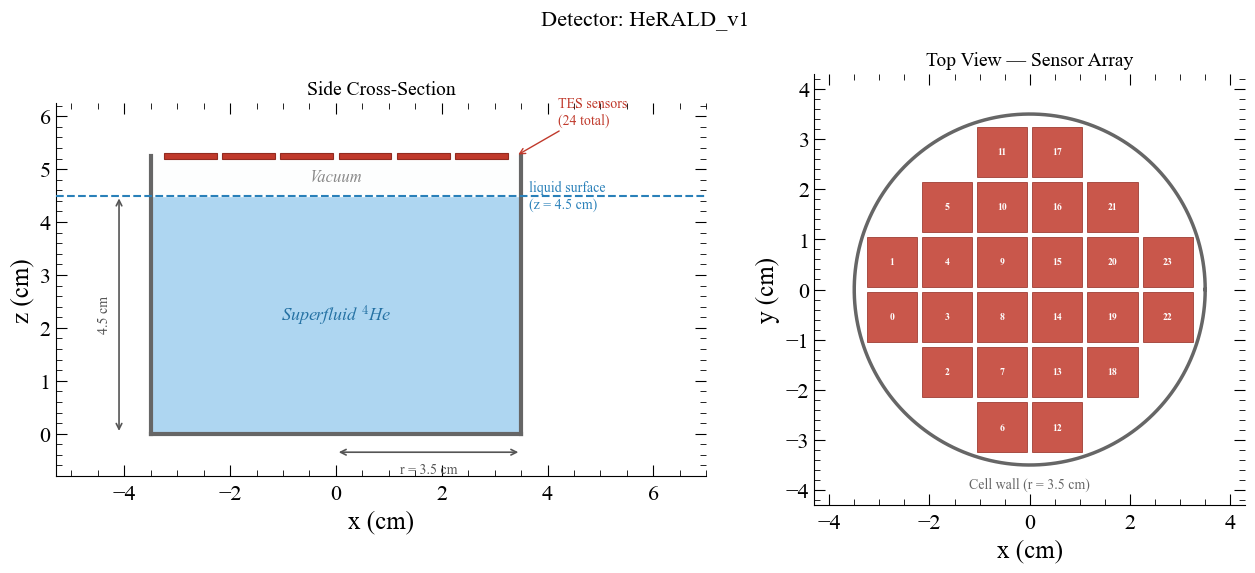

In [34]:
## Detector geometry diagram (HeRALD_v1)

cell_radius = detector_config['cell_radius']
fill_height = detector_config['fill_height']

sqcm_thickness = 0.1
sqcm_width = 1.0
sqcm_pitch = 1.1
sqcm_height = 5.2
cell_height = sqcm_height + 0.5 * sqcm_thickness  # 5.25 cm

array_map = np.array([[0,0,1,1,0,0],
                      [0,1,1,1,1,0],
                      [1,1,1,1,1,1],
                      [1,1,1,1,1,1],
                      [0,1,1,1,1,0],
                      [0,0,1,1,0,0]])

sensor_xy = []
for i in range(6):
    for j in range(6):
        if array_map[i, j] > 0.5:
            sensor_xy.append(((i - 2.5) * sqcm_pitch, (j - 2.5) * sqcm_pitch))

fig, (ax_side, ax_top) = plt.subplots(1, 2, figsize=(13, 5.5),
                                       gridspec_kw={'width_ratios': [1.3, 1]})

# --- Side cross-section (x-z plane) ---
wall_color = '#666666'
sensor_color = '#c0392b'
liquid_color = '#aed6f1'
vacuum_color = '#fdfefe'

ax_side.fill_between([-cell_radius, cell_radius], 0, fill_height,
                     color=liquid_color, zorder=0)
ax_side.fill_between([-cell_radius, cell_radius], fill_height, cell_height,
                     color=vacuum_color, zorder=0)

ax_side.plot([-cell_radius, -cell_radius], [0, cell_height], color=wall_color, lw=3, zorder=2)
ax_side.plot([cell_radius, cell_radius], [0, cell_height], color=wall_color, lw=3, zorder=2)
ax_side.plot([-cell_radius, cell_radius], [0, 0], color=wall_color, lw=3, zorder=2)

ax_side.axhline(fill_height, color='#2980b9', ls='--', lw=1.5, zorder=3)
ax_side.annotate(f'liquid surface\n(z = {fill_height} cm)',
                 xy=(cell_radius + 0.15, fill_height), fontsize=10, color='#2980b9',
                 va='center')

unique_x = sorted(set(x for x, y in sensor_xy))
for x0 in unique_x:
    rect = plt.Rectangle((x0 - sqcm_width/2, sqcm_height),
                          sqcm_width, sqcm_thickness,
                          fc=sensor_color, ec='#922b21', lw=0.8, zorder=4)
    ax_side.add_patch(rect)

ax_side.annotate('', xy=(-cell_radius - 0.6, 0), xytext=(-cell_radius - 0.6, fill_height),
                 arrowprops=dict(arrowstyle='<->', color='#555555', lw=1.2))
ax_side.text(-cell_radius - 0.75, fill_height / 2, f'{fill_height} cm',
             ha='right', va='center', fontsize=10, color='#555555', rotation=90)

ax_side.annotate('', xy=(0, -0.35), xytext=(cell_radius, -0.35),
                 arrowprops=dict(arrowstyle='<->', color='#555555', lw=1.2))
ax_side.text(cell_radius / 2, -0.55, f'r = {cell_radius} cm',
             ha='center', va='top', fontsize=10, color='#555555')

ax_side.text(0, fill_height / 2, 'Superfluid $^4$He', ha='center', va='center',
             fontsize=13, color='#2471a3', style='italic')
ax_side.text(0, (fill_height + sqcm_height) / 2, 'Vacuum', ha='center', va='center',
             fontsize=12, color='#888888', style='italic')

sensor_label_x = unique_x[-1] + sqcm_width / 2 + 0.15
ax_side.annotate(f'TES sensors\n({len(sensor_xy)} total)',
                 xy=(sensor_label_x, sqcm_height + sqcm_thickness / 2),
                 xytext=(sensor_label_x + 0.8, sqcm_height + 0.6),
                 fontsize=10, color=sensor_color, va='bottom',
                 arrowprops=dict(arrowstyle='->', color=sensor_color, lw=1))

ax_side.set_xlim(-cell_radius - 1.8, cell_radius + 3.5)
ax_side.set_ylim(-0.8, cell_height + 1.0)
ax_side.set_xlabel('x (cm)')
ax_side.set_ylabel('z (cm)')
ax_side.set_title('Side Cross-Section', fontsize=14)
ax_side.set_aspect('equal')
ax_side.spines[['top', 'right']].set_visible(False)

# --- Top-down view (x-y plane) with sensor IDs ---
theta = np.linspace(0, 2 * np.pi, 200)
ax_top.plot(cell_radius * np.cos(theta), cell_radius * np.sin(theta),
            color=wall_color, lw=2.5)

for sid, (x0, y0) in enumerate(sensor_xy):
    rect = plt.Rectangle((x0 - sqcm_width/2, y0 - sqcm_width/2),
                          sqcm_width, sqcm_width,
                          fc=sensor_color, ec='#922b21', lw=0.6, alpha=0.85, zorder=3)
    ax_top.add_patch(rect)
    ax_top.text(x0, y0, str(sid), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white', zorder=4)

ax_top.set_xlim(-cell_radius - 0.8, cell_radius + 0.8)
ax_top.set_ylim(-cell_radius - 0.8, cell_radius + 0.8)
ax_top.set_xlabel('x (cm)')
ax_top.set_ylabel('y (cm)')
ax_top.set_title('Top View — Sensor Array', fontsize=14)
ax_top.set_aspect('equal')
ax_top.spines[['top', 'right']].set_visible(False)

ax_top.text(0, -cell_radius - 0.45, f'Cell wall (r = {cell_radius} cm)',
            ha='center', fontsize=10, color=wall_color)

fig.suptitle(f'Detector: {detector_config["detector_geometry"]}', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# useful functions

In [74]:
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata as _griddata

def draw_recoil_energy_contours(ax, recoil_energies, x_detected, y_detected,
                                contour_energies=[100, 500, 1000, 5000],
                                color='#888888', lw=1.0, fontsize=9,
                                label_fmt=None, zorder=5, n_bins=40, smooth_sigma=3,
                                ls='--', label=None):
    """
    Draw contours of constant true recoil energy in the 2D detected-energy plane.

    Bins (x_detected, y_detected) on a grid, computes the mean recoil energy
    per bin, smooths, and draws iso-energy contour lines.
    """
    if label_fmt is None:
        def label_fmt(e):
            return f'{e/1000:g} keV' if e >= 1000 else f'{e:g} eV'

    x = np.asarray(x_detected, dtype=float)
    y = np.asarray(y_detected, dtype=float)
    z = np.asarray(recoil_energies, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[mask], y[mask], z[mask]
    if len(x) < 20:
        return

    # Use data range for binning, not axis limits
    pad = 0.02
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    dx = (x_max - x_min) * pad
    dy = (y_max - y_min) * pad
    x_range = [max(0, x_min - dx), x_max + dx]
    y_range = [max(0, y_min - dy), y_max + dy]

    # Scale n_bins to data size
    n = min(n_bins, max(15, int(np.sqrt(len(x) / 5))))

    ret = binned_statistic_2d(x, y, z, statistic='mean', bins=n,
                              range=[x_range, y_range])
    counts = binned_statistic_2d(x, y, z, statistic='count', bins=n,
                                 range=[x_range, y_range])

    xc = (ret.x_edge[:-1] + ret.x_edge[1:]) / 2
    yc = (ret.y_edge[:-1] + ret.y_edge[1:]) / 2
    Xi, Yi = np.meshgrid(xc, yc)
    Zi = ret.statistic.T
    Ci = counts.statistic.T.astype(float)

    valid = ~np.isnan(Zi) & (Ci >= 1)
    if valid.sum() < 10:
        return

    Zi_filled = _griddata((Xi[valid], Yi[valid]), Zi[valid], (Xi, Yi), method='nearest')
    Zi_smooth = gaussian_filter(Zi_filled, sigma=smooth_sigma)

    count_smooth = gaussian_filter(Ci, sigma=smooth_sigma)
    Zi_smooth[count_smooth < 0.1] = np.nan

    zmin, zmax = np.nanmin(Zi_smooth), np.nanmax(Zi_smooth)
    levels = sorted([e for e in contour_energies if zmin <= e <= zmax])
    if not levels:
        return

    cs = ax.contour(Xi, Yi, Zi_smooth, levels=levels,
                    colors=color, linewidths=lw, linestyles=ls, zorder=zorder)
    ax.clabel(cs, inline=True, fontsize=fontsize,
              fmt={e: label_fmt(e) for e in levels})

    if label is not None:
        ax.plot([], [], color=color, ls=ls, lw=lw, label=label)

# Theoretical Yield Curves

These plots use the analytic yield functions directly — no simulation data needed.

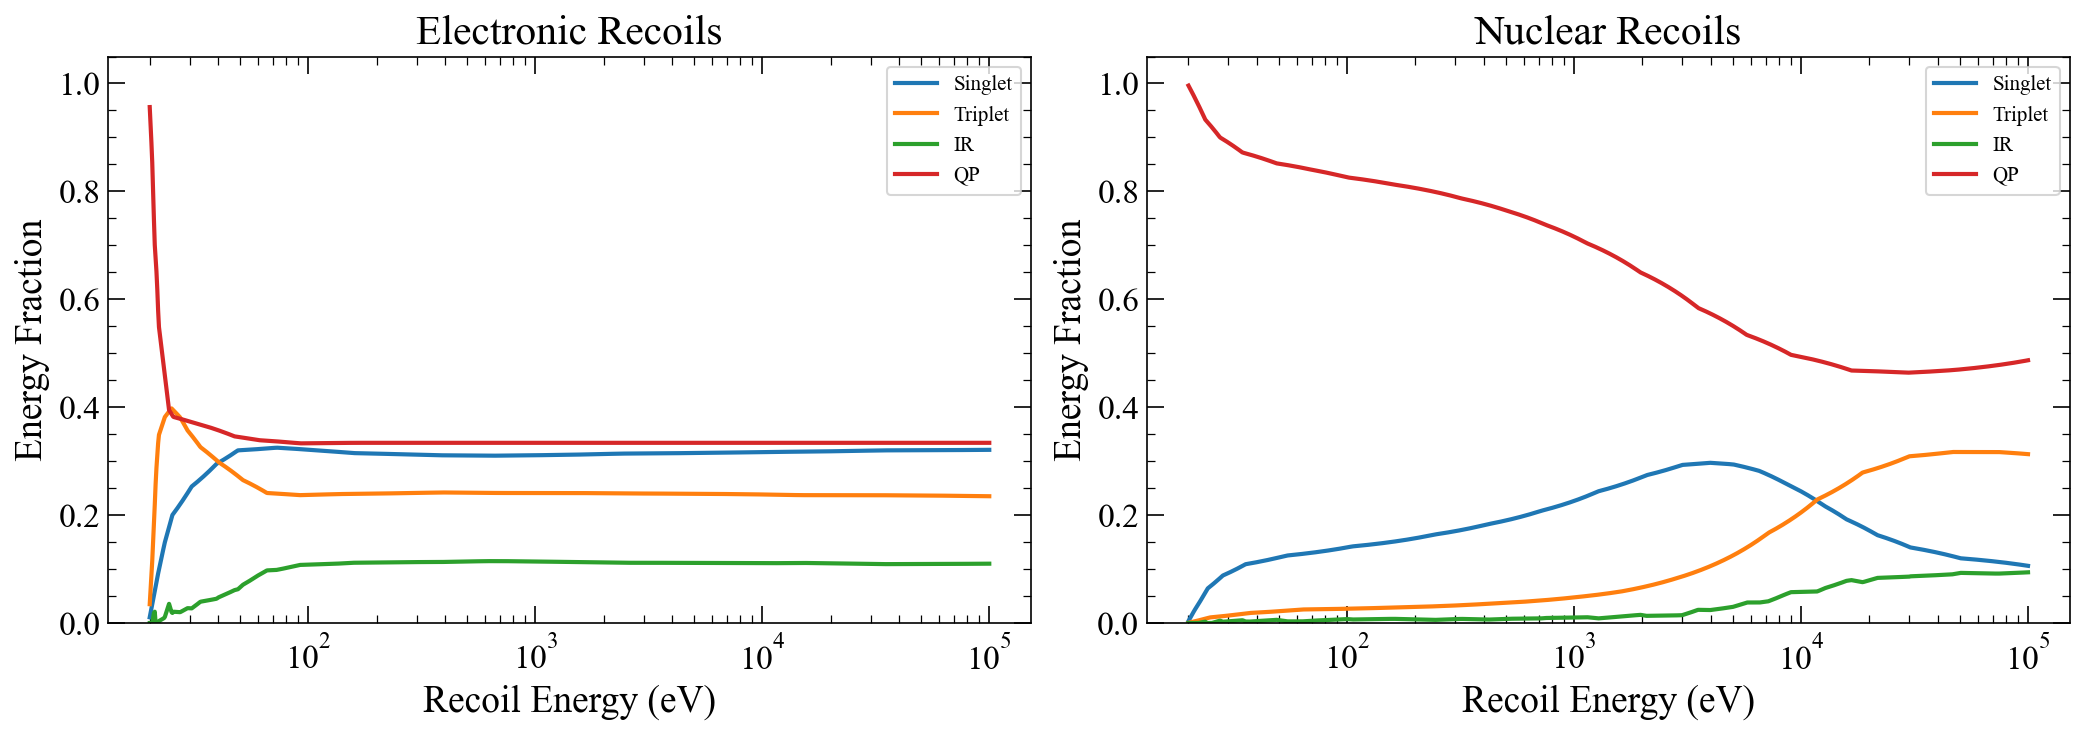

In [39]:
E_theory = np.geomspace(20, 100000, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, interaction, title in zip(axes, ['ER', 'NR'],
                                   ['Electronic Recoils', 'Nuclear Recoils']):
    s, t, qp, ir = H.GetEnergyChannelFractions(E_theory, interaction)
    ax.plot(E_theory, s, color=CHANNEL_COLORS[0], label='Singlet')
    ax.plot(E_theory, t, color=CHANNEL_COLORS[1], label='Triplet')
    ax.plot(E_theory, ir, color=CHANNEL_COLORS[2], label='IR')
    ax.plot(E_theory, qp, color=CHANNEL_COLORS[3], label='QP')
    ax.set_xscale('log')
    ax.set_xlabel('Recoil Energy (eV)')
    ax.set_ylabel('Energy Fraction')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

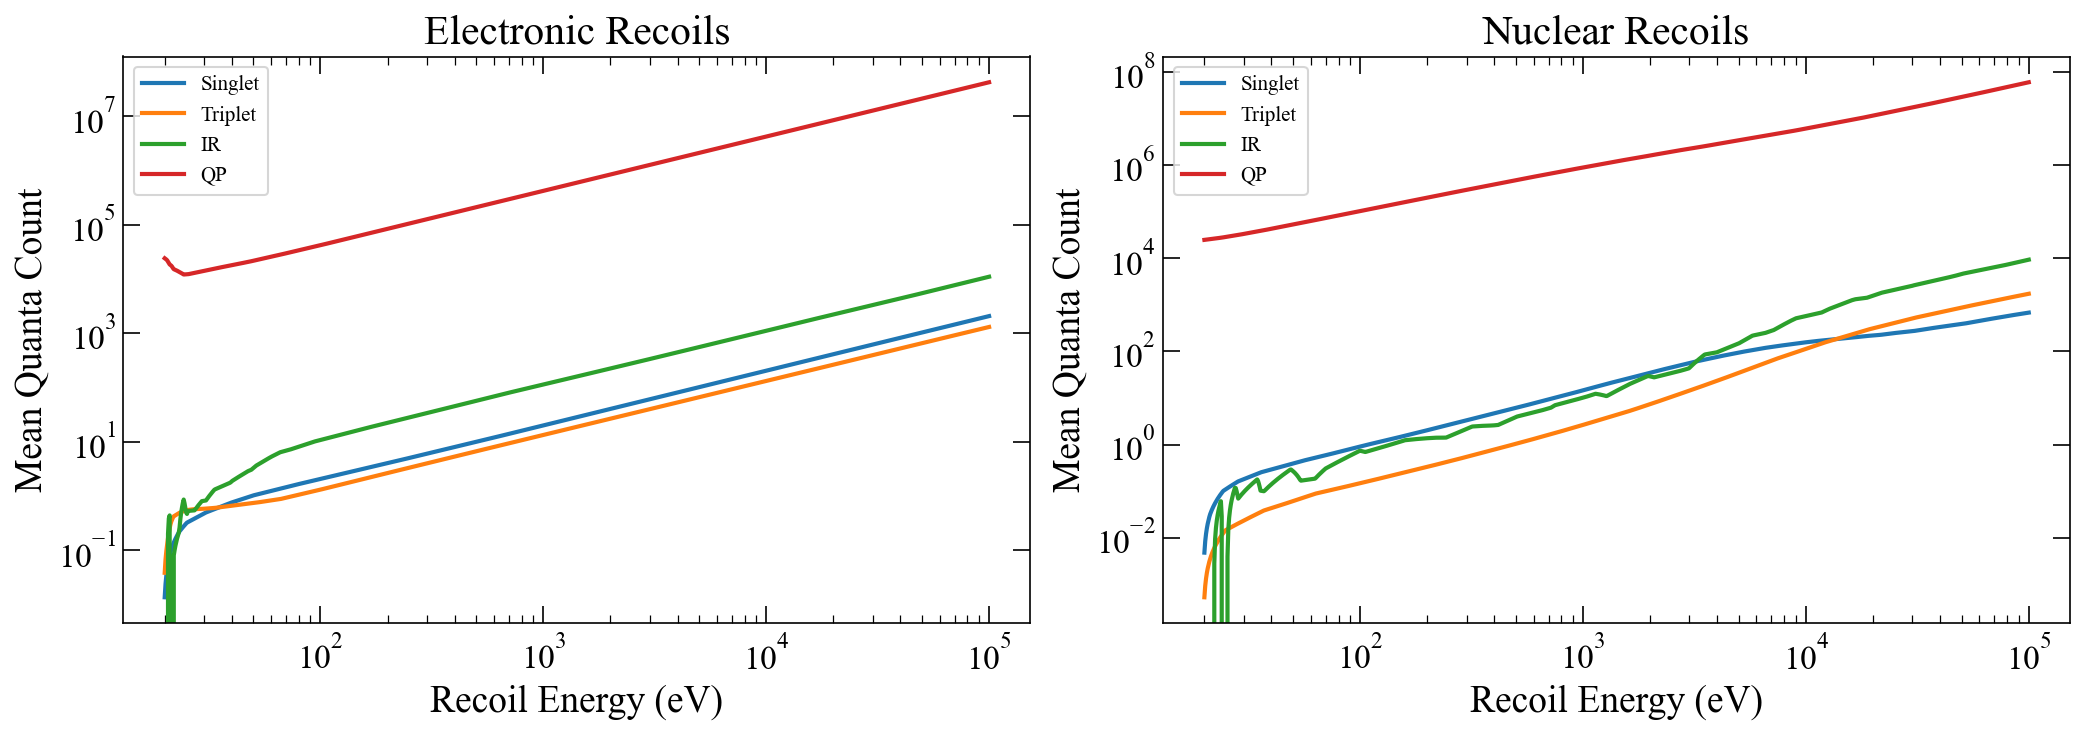

In [40]:
# Mean quanta counts vs. energy
avg_qp_energy = H.Average_QPEnergy(T=2.)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, interaction, title in zip(axes, ['ER', 'NR'],
                                   ['Electronic Recoils', 'Nuclear Recoils']):
    s, t, qp, ir = H.GetEnergyChannelFractions(E_theory, interaction)
    n_singlet = s * E_theory / 15.5
    n_triplet = t * E_theory / 18.0
    n_ir = ir * E_theory / 1.0
    n_qp = qp * E_theory / avg_qp_energy

    ax.plot(E_theory, n_singlet, color=CHANNEL_COLORS[0], label='Singlet')
    ax.plot(E_theory, n_triplet, color=CHANNEL_COLORS[1], label='Triplet')
    ax.plot(E_theory, n_ir, color=CHANNEL_COLORS[2], label='IR')
    ax.plot(E_theory, n_qp, color=CHANNEL_COLORS[3], label='QP')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Recoil Energy (eV)')
    ax.set_ylabel('Mean Quanta Count')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# Inspect Input Recoil Spectrum

(0.0, 10000.0)

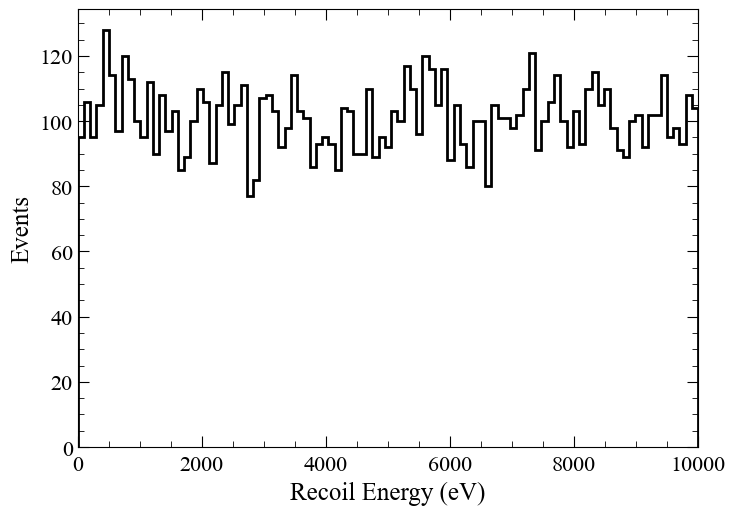

In [39]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(recoil_energies, bins=np.linspace(0,10000,100), lw=2, color='black', histtype='step')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Events')
ax.set_xlim(0,10000)


# Plot Total Detected Energy in Each Signal Channel

Summing over sensors

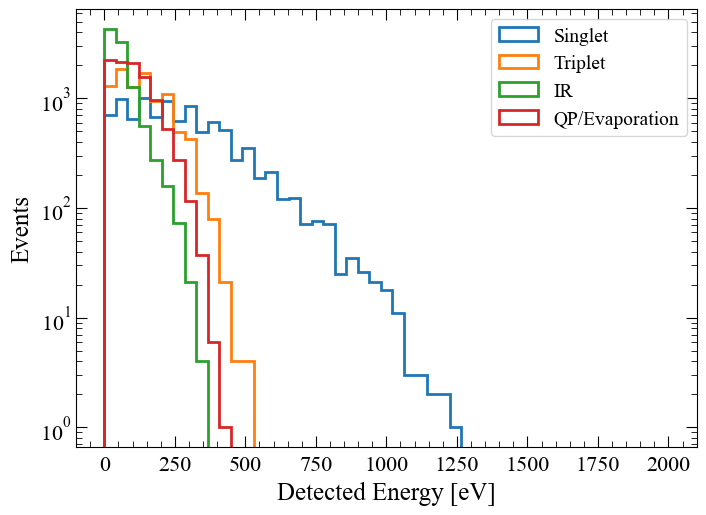

In [41]:
fig, ax = plt.subplots(1, 1, dpi=100)

bins = np.linspace(0,2000,50)

for ch in range(4):
    vals = detected_energy[:, ch]
    vals = vals[vals > 0]
    ax.hist(vals, bins=bins, lw=2, histtype='step', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch])

ax.set_xlabel('Detected Energy [eV]')
ax.set_ylabel('Events')
ax.set_yscale('log')
ax.legend(frameon=True, loc='upper right',fontsize=14)


## 2D Versions

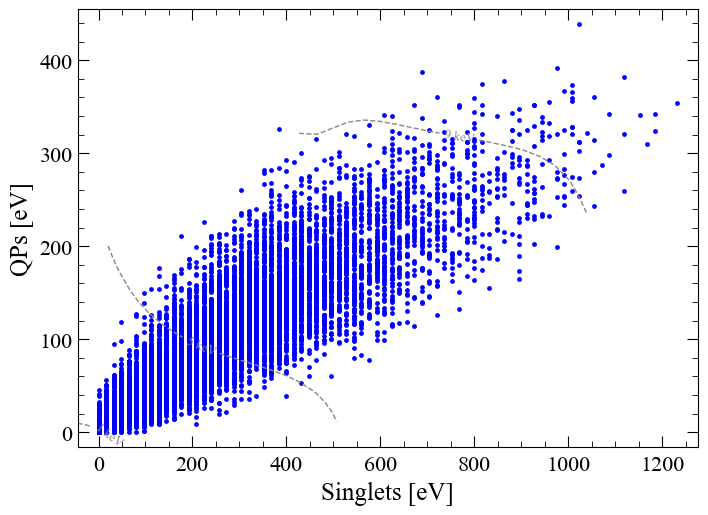

In [55]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(detected_energy[:,0], detected_energy[:,3], s=6, color='blue')

ax.set_xlabel('Singlets [eV]')
ax.set_ylabel('QPs [eV]')

draw_recoil_energy_contours(ax, recoil_energies, detected_energy[:,0], detected_energy[:,3],
                            contour_energies=[1000, 5000, 9000])

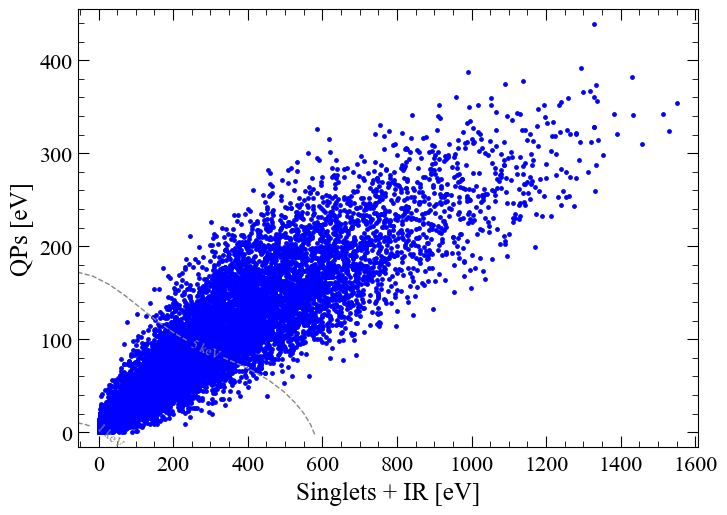

In [56]:
fig, ax = plt.subplots(1,1,dpi=100)

x_det = detected_energy[:,0] + detected_energy[:,2]
ax.scatter(x_det, detected_energy[:,3], s=6, color='blue')

ax.set_xlabel('Singlets + IR [eV]')
ax.set_ylabel('QPs [eV]')

draw_recoil_energy_contours(ax, recoil_energies, x_det, detected_energy[:,3],
                            contour_energies=[100, 500, 1000, 5000])

# Fraction of Energy detected per channel

Fraction of generated quanta that are detected, per channel.

In [7]:
def binned_stats(energies, values, n_bins=20):
    """Compute mean and SEM of values in log-spaced energy bins, ignoring NaNs."""
    bins = np.geomspace(energies.min() * 0.9, energies.max() * 1.1, n_bins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    means = np.full(n_bins, np.nan)
    sems = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask = (energies >= bins[i]) & (energies < bins[i+1])
        v = values[mask]
        v = v[~np.isnan(v)]
        if len(v) > 1:
            means[i] = np.mean(v)
            sems[i] = np.std(v) / np.sqrt(len(v))
    return bin_centers, means, sems


In [ ]:
from scipy.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata as _griddata

def draw_recoil_energy_contours(ax, recoil_energies, x_detected, y_detected,
                                contour_energies=[100, 500, 1000, 5000],
                                color='#888888', lw=1.0, fontsize=9,
                                label_fmt=None, zorder=5, n_bins=40, smooth_sigma=3,
                                ls='--', label=None):
    """
    Draw contours of constant true recoil energy in the 2D detected-energy plane.

    Bins (x_detected, y_detected) on a grid, computes the mean recoil energy
    per bin, smooths, and draws iso-energy contour lines.
    """
    if label_fmt is None:
        def label_fmt(e):
            return f'{e/1000:g} keV' if e >= 1000 else f'{e:g} eV'

    x = np.asarray(x_detected, dtype=float)
    y = np.asarray(y_detected, dtype=float)
    z = np.asarray(recoil_energies, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[mask], y[mask], z[mask]
    if len(x) < 20:
        return

    # Use data range for binning, not axis limits
    pad = 0.02
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    dx = (x_max - x_min) * pad
    dy = (y_max - y_min) * pad
    x_range = [max(0, x_min - dx), x_max + dx]
    y_range = [max(0, y_min - dy), y_max + dy]

    # Scale n_bins to data size
    n = min(n_bins, max(15, int(np.sqrt(len(x) / 5))))

    ret = binned_statistic_2d(x, y, z, statistic='mean', bins=n,
                              range=[x_range, y_range])
    counts = binned_statistic_2d(x, y, z, statistic='count', bins=n,
                                 range=[x_range, y_range])

    xc = (ret.x_edge[:-1] + ret.x_edge[1:]) / 2
    yc = (ret.y_edge[:-1] + ret.y_edge[1:]) / 2
    Xi, Yi = np.meshgrid(xc, yc)
    Zi = ret.statistic.T
    Ci = counts.statistic.T.astype(float)

    valid = ~np.isnan(Zi) & (Ci >= 1)
    if valid.sum() < 10:
        return

    Zi_filled = _griddata((Xi[valid], Yi[valid]), Zi[valid], (Xi, Yi), method='nearest')
    Zi_smooth = gaussian_filter(Zi_filled, sigma=smooth_sigma)

    count_smooth = gaussian_filter(Ci, sigma=smooth_sigma)
    Zi_smooth[count_smooth < 0.1] = np.nan

    zmin, zmax = np.nanmin(Zi_smooth), np.nanmax(Zi_smooth)
    levels = sorted([e for e in contour_energies if zmin <= e <= zmax])
    if not levels:
        return

    cs = ax.contour(Xi, Yi, Zi_smooth, levels=levels,
                    colors=color, linewidths=lw, linestyles=ls, zorder=zorder)
    ax.clabel(cs, inline=True, fontsize=fontsize,
              fmt={e: label_fmt(e) for e in levels})

    if label is not None:
        ax.plot([], [], color=color, ls=ls, lw=lw, label=label)

/var/folders/w0/n2ws7mw16vb_37jrv5hgk81h0000gn/T/ipykernel_64854/3578369584.py:8: RuntimeWarning: invalid value encountered in divide
  eff = np.where(gen > 0, det / gen, np.nan)


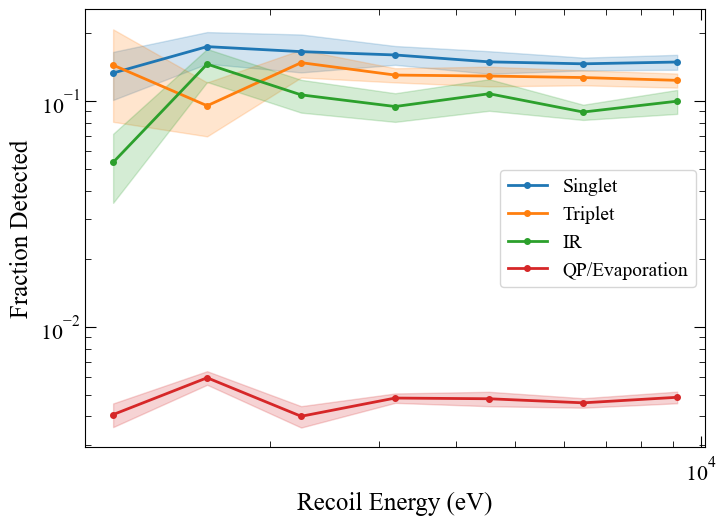

In [8]:
n_bins = 20

fig, ax = plt.subplots(1,1,dpi=100)

for ch in range(4):
    gen = n_quanta_generated[:, ch].astype(float)
    det = detected_count[:, ch].astype(float)
    eff = np.where(gen > 0, det / gen, np.nan)
    bc, mu, sem = binned_stats(recoil_energies, eff, n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Fraction Detected')
ax.legend(frameon=True, loc='best', fontsize=14)


## Per-Channel Detected Energy vs. Recoil Energy

Mean detected energy in each channel as a function of recoil energy, with standard-error bands.

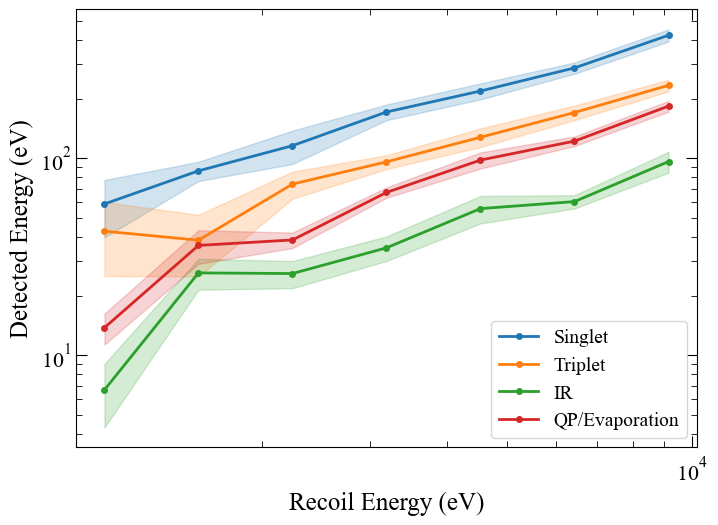

In [9]:
n_bins = 20

fig, ax = plt.subplots(1,1,dpi=100)

for ch in range(4):
    bc, mu, sem = binned_stats(recoil_energies, detected_energy[:, ch], n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Detected Energy (eV)')
ax.legend(frameon=True, loc='best', fontsize=14)


# Arrival Time Distributions

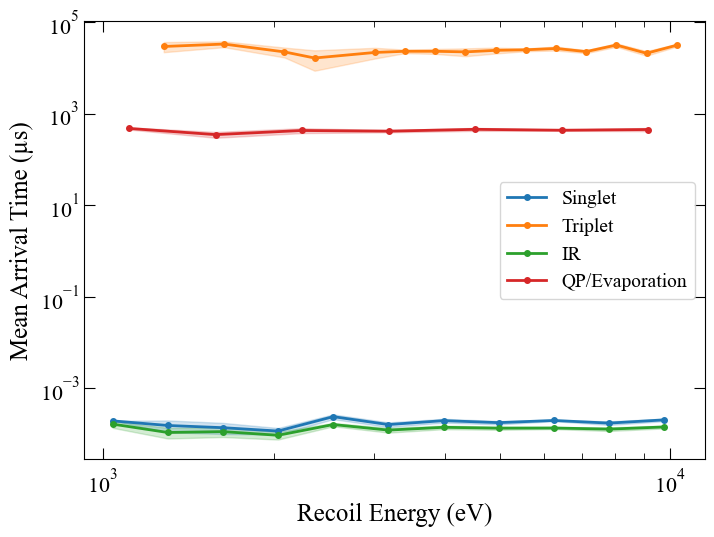

In [10]:
n_bins = 20

fig, ax = plt.subplots(1,1, dpi=100)

for ch in range(4):
    times = mean_arrival_time[:, ch]
    valid_times = ~np.isnan(times)
    if np.sum(valid_times) < 2:
        continue
    bc, mu, sem = binned_stats(recoil_energies[valid_times],
                                times[valid_times], n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Mean Arrival Time (µs)')
ax.legend(frameon=True, loc='best', fontsize=14)



# Arrival Times per event

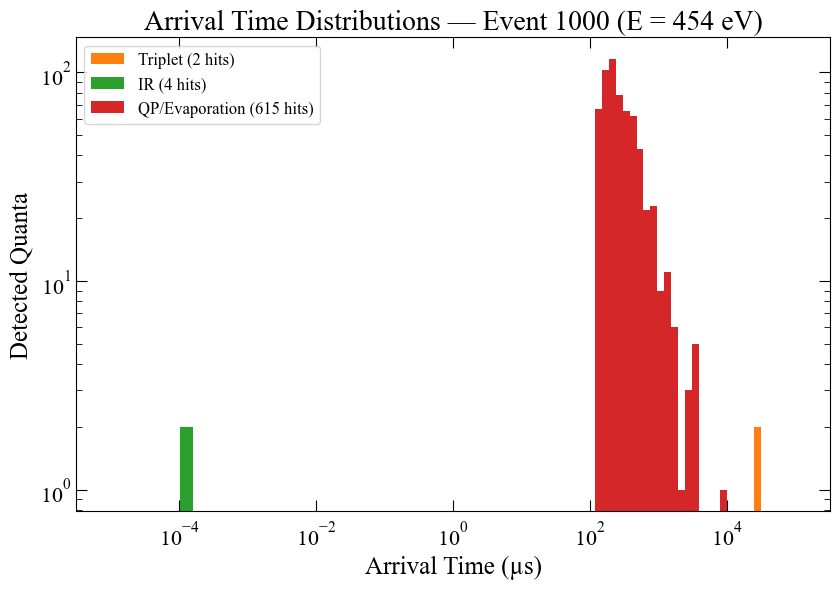

In [127]:
import h5py

H5_FILE = DATA_FILE.replace('.npz', '.h5')

# Set EVENT_INDEX to a specific event, or None to sum over all events
EVENT_INDEX = 1000

channel_keys = ['singlet', 'triplet', 'ir', 'qp']

fig, ax = plt.subplots(1, 1, dpi=100)

with h5py.File(H5_FILE, 'r') as f:
    if EVENT_INDEX is not None:
        event_indices = [EVENT_INDEX]
        title_suffix = f'Event {EVENT_INDEX} (E = {recoil_energies[EVENT_INDEX]:.0f} eV)'
    else:
        event_indices = range(int(f.attrs['n_events']))
        title_suffix = f'All {int(f.attrs["n_events"])} Events'

    for ch, ch_key in enumerate(channel_keys):
        all_times = []
        for evt_i in event_indices:
            evt = f['events'].get(str(evt_i))
            if evt is None:
                continue
            ch_grp = evt.get(ch_key)
            if ch_grp is None:
                continue
            for s_key in ch_grp.keys():
                times = ch_grp[s_key]['arrival_times'][:]
                if len(times) > 0:
                    all_times.append(times)

        if all_times:
            all_times = np.concatenate(all_times)
            all_times = all_times[all_times > 0]
            if len(all_times) > 0:
                bins = np.geomspace(1e-5, 1e5, 100)
                ax.hist(all_times, bins=bins, alpha=1, color=CHANNEL_COLORS[ch],
                        label=f'{CHANNEL_NAMES[ch]} ({len(all_times)} hits)')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Arrival Time (µs)')
ax.set_ylabel('Detected Quanta')
ax.set_title(f'Arrival Time Distributions — {title_suffix}')
ax.legend(frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

# Compare WIMP and Flat ER

In [13]:
ER_FILE = 'Sims/Spectrum_Flat_ER_energyMin_10_energyMax_10000_nEvents_10000_Heraldv1.npz'
WIMP_FILE = 'Sims/Spectrum_Flat_NR_energyMin_10_energyMax_10000_nEvents_10000_Heraldv1.npz'

er_data = np.load(ER_FILE, allow_pickle=True)
wimp_data = np.load(WIMP_FILE, allow_pickle=True)

print(f'ER:   {len(er_data["recoil_energies"])} events, spectrum={str(er_data["spectrum_mode"])}')
print(f'NR:   {len(wimp_data["recoil_energies"])} events, spectrum={str(wimp_data["spectrum_mode"])}')
#print(f'WIMP: {len(wimp_data["recoil_energies"])} events, mass={float(wimp_data["wimp_mass"])} MeV')

ER:   10000 events, spectrum=flat
NR:   10000 events, spectrum=flat


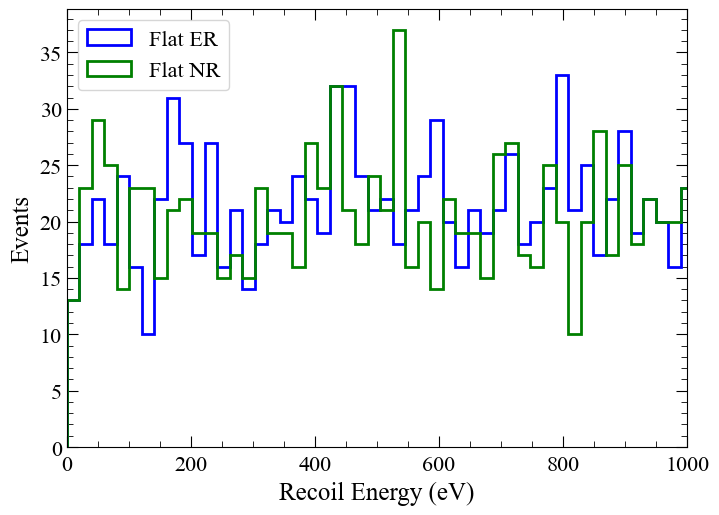

In [58]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_data['recoil_energies'], bins=np.linspace(0,2000,100), lw=2, color='blue', histtype='step', label='Flat ER')
ax.hist(wimp_data['recoil_energies'], bins=np.linspace(0,2000,100), lw=2, color='green', histtype='step', label=f'Flat NR')

ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Events')
ax.set_xlim(0,1000)
ax.legend(frameon=True, fontsize=16)

## Load detected energy in each response channel

Also apply detector smearing

In [17]:
def apply_resolution(energy, sigma, per_sensor=False):
    """
    Apply Gaussian energy resolution smearing to detected signals.

    Parameters
    ----------
    energy : array
        If per_sensor=False: (n_events, 4) total detected energy per channel.  data['detected_energy'] 
        If per_sensor=True:  (n_events, 4, n_sensors) per-sensor detected energy. data['sensor_det_energy']
    sigma : float
        Detector energy resolution (1-sigma) in eV, e.g. 0.500 for 500 meV.
    per_sensor : bool
        If True, apply independent noise to each sensor then sum over sensors.
        If False, apply one noise draw per channel total.

    Returns
    -------
    measured_energy : (n_events, 4) array
        Resolution-smeared detected energy per channel.
    """
    smeared = energy + np.random.normal(0, sigma, size=energy.shape)
    if per_sensor:
        return smeared.sum(axis=2)
    return smeared

In [18]:
er_prompt_photon = er_data['detected_energy'][:, 0] + er_data['detected_energy'][:, 2]
er_delayed_photon = er_data['detected_energy'][:, 1] 
er_qp = er_data['detected_energy'][:, 3]

wimp_prompt_photon = wimp_data['detected_energy'][:, 0] + wimp_data['detected_energy'][:, 2]
wimp_delayed_photon = wimp_data['detected_energy'][:, 1] 
wimp_qp = wimp_data['detected_energy'][:, 3]

# resolution
sigma = 1.0

er_prompt_photon_smeared = apply_resolution(er_prompt_photon, sigma)
er_delayed_photon_smeared = apply_resolution(er_delayed_photon, sigma)
er_qp_smeared = apply_resolution(er_qp, sigma)

wimp_prompt_photon_smeared = apply_resolution(wimp_prompt_photon, sigma)
wimp_delayed_photon_smeared = apply_resolution(wimp_delayed_photon, sigma)
wimp_qp_smeared = apply_resolution(wimp_qp, sigma)

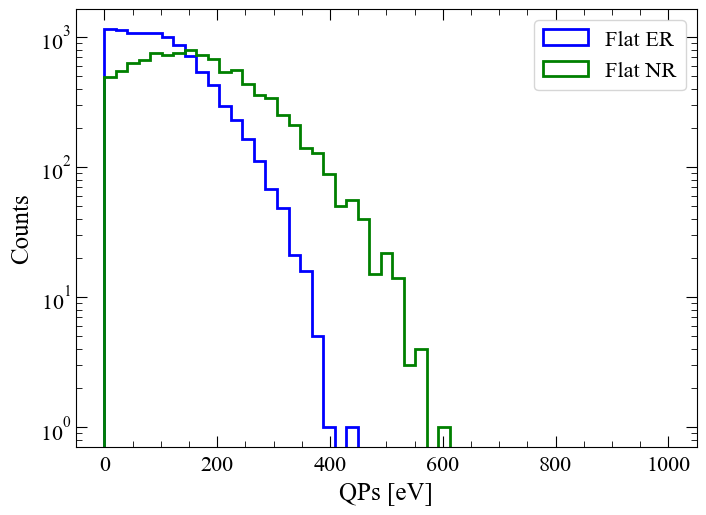

In [25]:
bins = np.linspace(0,1000,50)

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_qp, bins=bins, lw=2, histtype='step', color='blue', label='Flat ER')
ax.hist(wimp_qp, bins=bins, lw=2, histtype='step', color='green', label=f'Flat NR')

ax.set_yscale('log')
ax.set_xlabel('QPs [eV]')
ax.set_ylabel('Counts')
ax.legend(frameon=True, fontsize=16)

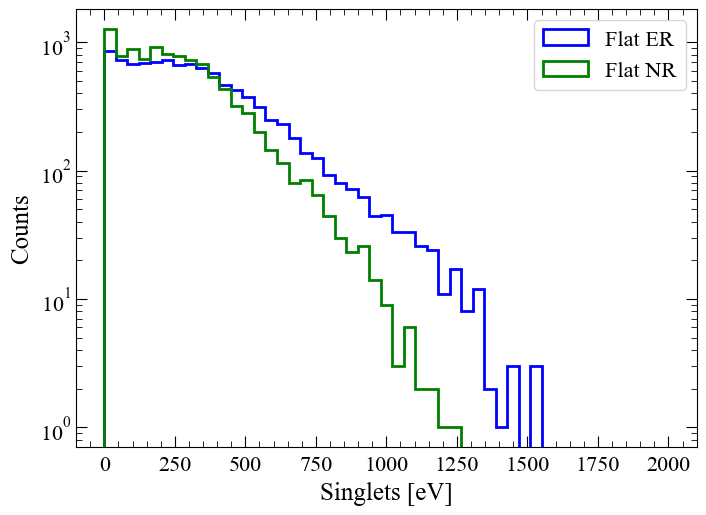

In [26]:
bins = np.linspace(0,2000,50)

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_prompt_photon, bins=bins, lw=2, histtype='step', color='blue', label='Flat ER')
ax.hist(wimp_prompt_photon, bins=bins, lw=2, histtype='step', color='green', label=f'Flat NR')

ax.set_yscale('log')
ax.set_xlabel('Singlets [eV]')
ax.set_ylabel('Counts')
ax.legend(frameon=True, fontsize=16)

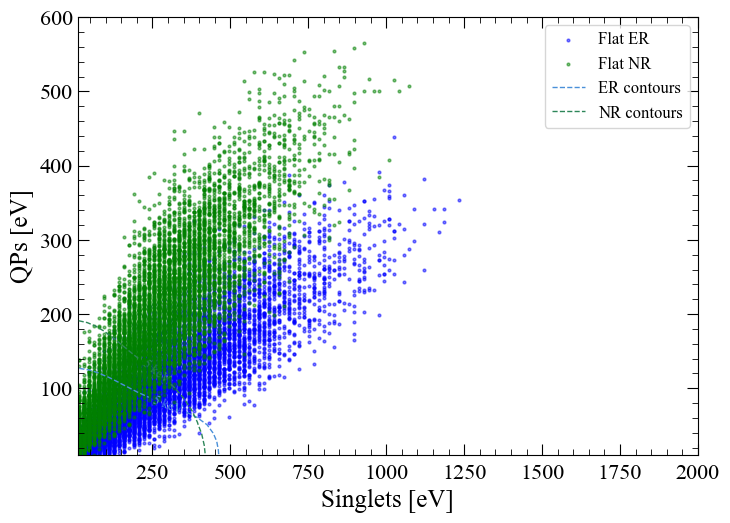

In [80]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(er_data['detected_energy'][:, 0], er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(wimp_data['detected_energy'][:, 0], wimp_qp, s=4, alpha=0.5, color='green', label=f'Flat NR')

ax.set_ylim(10,600)
ax.set_xlim(10,2000)
ax.set_xlabel('Singlets [eV]')
ax.set_ylabel('QPs [eV]')
#ax.set_xscale('log')
#ax.set_yscale('log')

draw_recoil_energy_contours(ax, er_data['recoil_energies'],
                            er_data['detected_energy'][:, 0], er_qp,
                            contour_energies=[1000, 5000],
                            color='#4a90d9', label='ER contours')
draw_recoil_energy_contours(ax, wimp_data['recoil_energies'],
                            wimp_data['detected_energy'][:, 0], wimp_qp,
                            contour_energies=[1000, 5000],
                            color='#2d8659', label='NR contours')

ax.legend(frameon=True, fontsize=12)

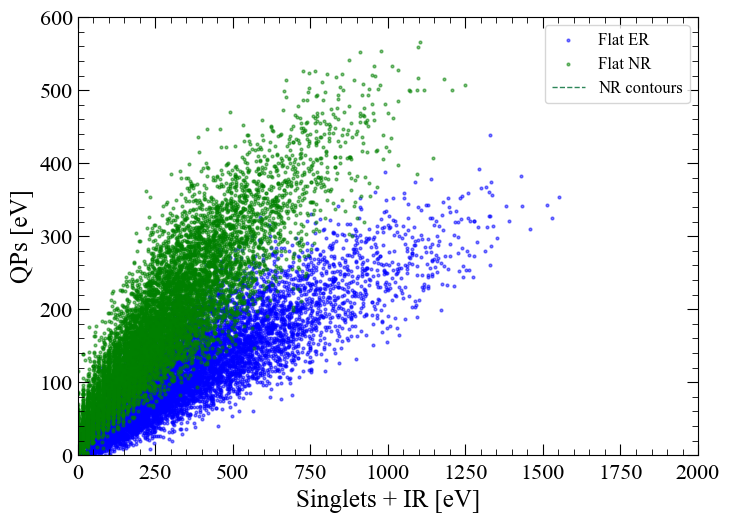

In [71]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(er_prompt_photon, er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(wimp_prompt_photon, wimp_qp, s=4, alpha=0.5, color='green', label=f'Flat NR')

ax.set_ylim(0,600)
ax.set_xlim(0,2000)
ax.set_xlabel('Singlets + IR [eV]')
ax.set_ylabel('QPs [eV]')

draw_recoil_energy_contours(ax, er_data['recoil_energies'],
                            er_prompt_photon, er_qp,
                            contour_energies=[100, 500, 1000, 2000],
                            color='#4a90d9', label='ER contours')
draw_recoil_energy_contours(ax, wimp_data['recoil_energies'],
                            wimp_prompt_photon, wimp_qp,
                            contour_energies=[100, 500, 1000, 2000],
                            color='#2d8659', label='NR contours')
ax.legend(frameon=True, fontsize=12)

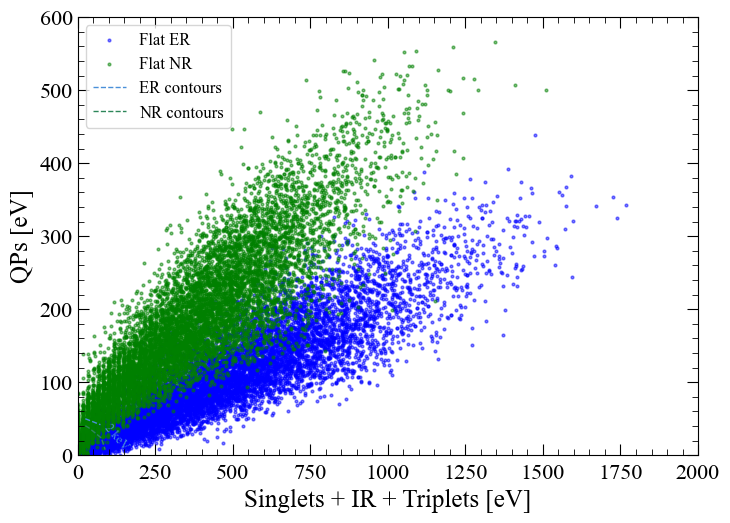

In [72]:
fig, ax = plt.subplots(1,1,dpi=100)

er_all_photon = er_prompt_photon + er_delayed_photon
nr_all_photon = wimp_prompt_photon + wimp_delayed_photon

ax.scatter(er_all_photon, er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(nr_all_photon, wimp_qp, s=4, alpha=0.5, color='green', label=f'Flat NR')

ax.set_ylim(0,600)
ax.set_xlim(0,2000)
ax.set_xlabel('Singlets + IR + Triplets [eV]')
ax.set_ylabel('QPs [eV]')

draw_recoil_energy_contours(ax, er_data['recoil_energies'],
                            er_all_photon, er_qp,
                            contour_energies=[100, 500, 1000, 2000],
                            color='#4a90d9', label='ER contours')
draw_recoil_energy_contours(ax, wimp_data['recoil_energies'],
                            nr_all_photon, wimp_qp,
                            contour_energies=[100, 500, 1000, 2000],
                            color='#2d8659', label='NR contours')
ax.legend(frameon=True, fontsize=12)